In [2]:
import numpy as np
import pandas as pd

import os, sys

# find the folder that contains "idsia_mpc"
# In Jupyter, __file__ is not defined, so start from the current working directory
current_dir = os.getcwd()

while True:
    if os.path.exists(os.path.join(current_dir, "idsia_mpc")):
        PROJECT_ROOT = current_dir
        break
    parent = os.path.dirname(current_dir)
    if parent == current_dir:  # reached filesystem root
        raise RuntimeError("Could not find project root containing 'idsia_mpc'")
    current_dir = parent

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Using project root:", PROJECT_ROOT)

from idsia_mpc.control_engineering_practice.plot_utils import setup_matplotlib

Using project root: /home/rbusetto/nanodrone-sysid-mpc


In [3]:
setup_matplotlib()

# === Config ===
train_trajs = ["random1", "random2"]
test_trajs = ["square"]

# === File paths ===
OUT_FOLDER = os.path.join(
    PROJECT_ROOT,
    "idsia_mpc",
    "control_engineering_practice",
    "sysid",
    "out",
    "predictions",
    "real"
)

# Ensure the output folder exists
os.makedirs(OUT_FOLDER, exist_ok=True)

# Construct file paths
train_name = "_".join(train_trajs)
test_name = "_".join(test_trajs)

file_lstm = os.path.join(
    OUT_FOLDER,
    f"lstm_{train_name}_model_multistep",
    f"{test_name}_multistep.parquet"
)

file_base = os.path.join(
    OUT_FOLDER,
    "baseline_model_multistep",
    f"{test_name}_multistep.parquet"
)

file_neur = os.path.join(
    OUT_FOLDER,
    f"neural_{train_name}_model_multistep",
    f"{test_name}_multistep.parquet"
)

file_phys = os.path.join(
    OUT_FOLDER,
    f"physics_model_multistep",
    f"{test_name}_multistep.parquet"
)

print("LSTM file path:", file_lstm)
print("Baseline file path:", file_base)

# === Read CSVs ===
df_lstm = pd.read_parquet(file_lstm)
df_base = pd.read_parquet(file_base)
df_neur = pd.read_parquet(file_neur)
df_phys = pd.read_parquet(file_phys)

print("✅ Loaded datasets:")
print(f"  LSTM model: {df_lstm.shape}")
print(f"  Baseline model: {df_base.shape}")
print(f"  Neural model: {df_neur.shape}")

LSTM file path: /home/rbusetto/nanodrone-sysid-mpc/idsia_mpc/control_engineering_practice/sysid/out/predictions/real/lstm_random1_random2_model_multistep/square_multistep.parquet
Baseline file path: /home/rbusetto/nanodrone-sysid-mpc/idsia_mpc/control_engineering_practice/sysid/out/predictions/real/baseline_model_multistep/square_multistep.parquet
✅ Loaded datasets:
  LSTM model: (1850, 613)
  Baseline model: (1850, 613)
  Neural model: (1850, 613)


In [4]:
import numpy as np
max_horizon = 20

def quat_SO3_log(q, eps=1e-6):
    """
    Log map from quaternion to so(3) (rotation vector), NumPy version.
    q: (..., 4) array [x, y, z, w], assumed normalized.
    Returns: (..., 3) rotation vector.
    """
    v = q[..., :3]        # vector part (x, y, z)
    w = q[..., 3:]        # scalar part (w)
    norm_v = np.linalg.norm(v, axis=-1, keepdims=True)

    # Clamp w to valid range [-1, 1]
    w_clamped = np.clip(w, -1.0 + eps, 1.0 - eps)

    # Compute rotation angle
    angle = 2 * np.arctan2(norm_v, w_clamped)

    # Default case
    log_q = (angle / (norm_v + eps)) * v

    # Small-angle fallback: log(q) ≈ 2*v
    small = norm_v < eps
    log_q[small.squeeze()] = 2.0 * v[small.squeeze()]

    return log_q


q = df_phys[['qx','qy','qz','qw']].to_numpy()
r = quat_SO3_log(q)
df_phys[['rx','ry','rz']] = r

# --- Transform all predicted quaternions per horizon ---
for h in range(1, max_horizon + 1):
    cols = [f"qx_pred_h{h}", f"qy_pred_h{h}", f"qz_pred_h{h}", f"qw_pred_h{h}"]
    if all(c in df_phys.columns for c in cols):
        q_pred = df_phys[cols].to_numpy()
        r_pred = quat_SO3_log(q_pred)
        df_phys[[f"rx_pred_h{h}", f"ry_pred_h{h}", f"rz_pred_h{h}"]] = r_pred

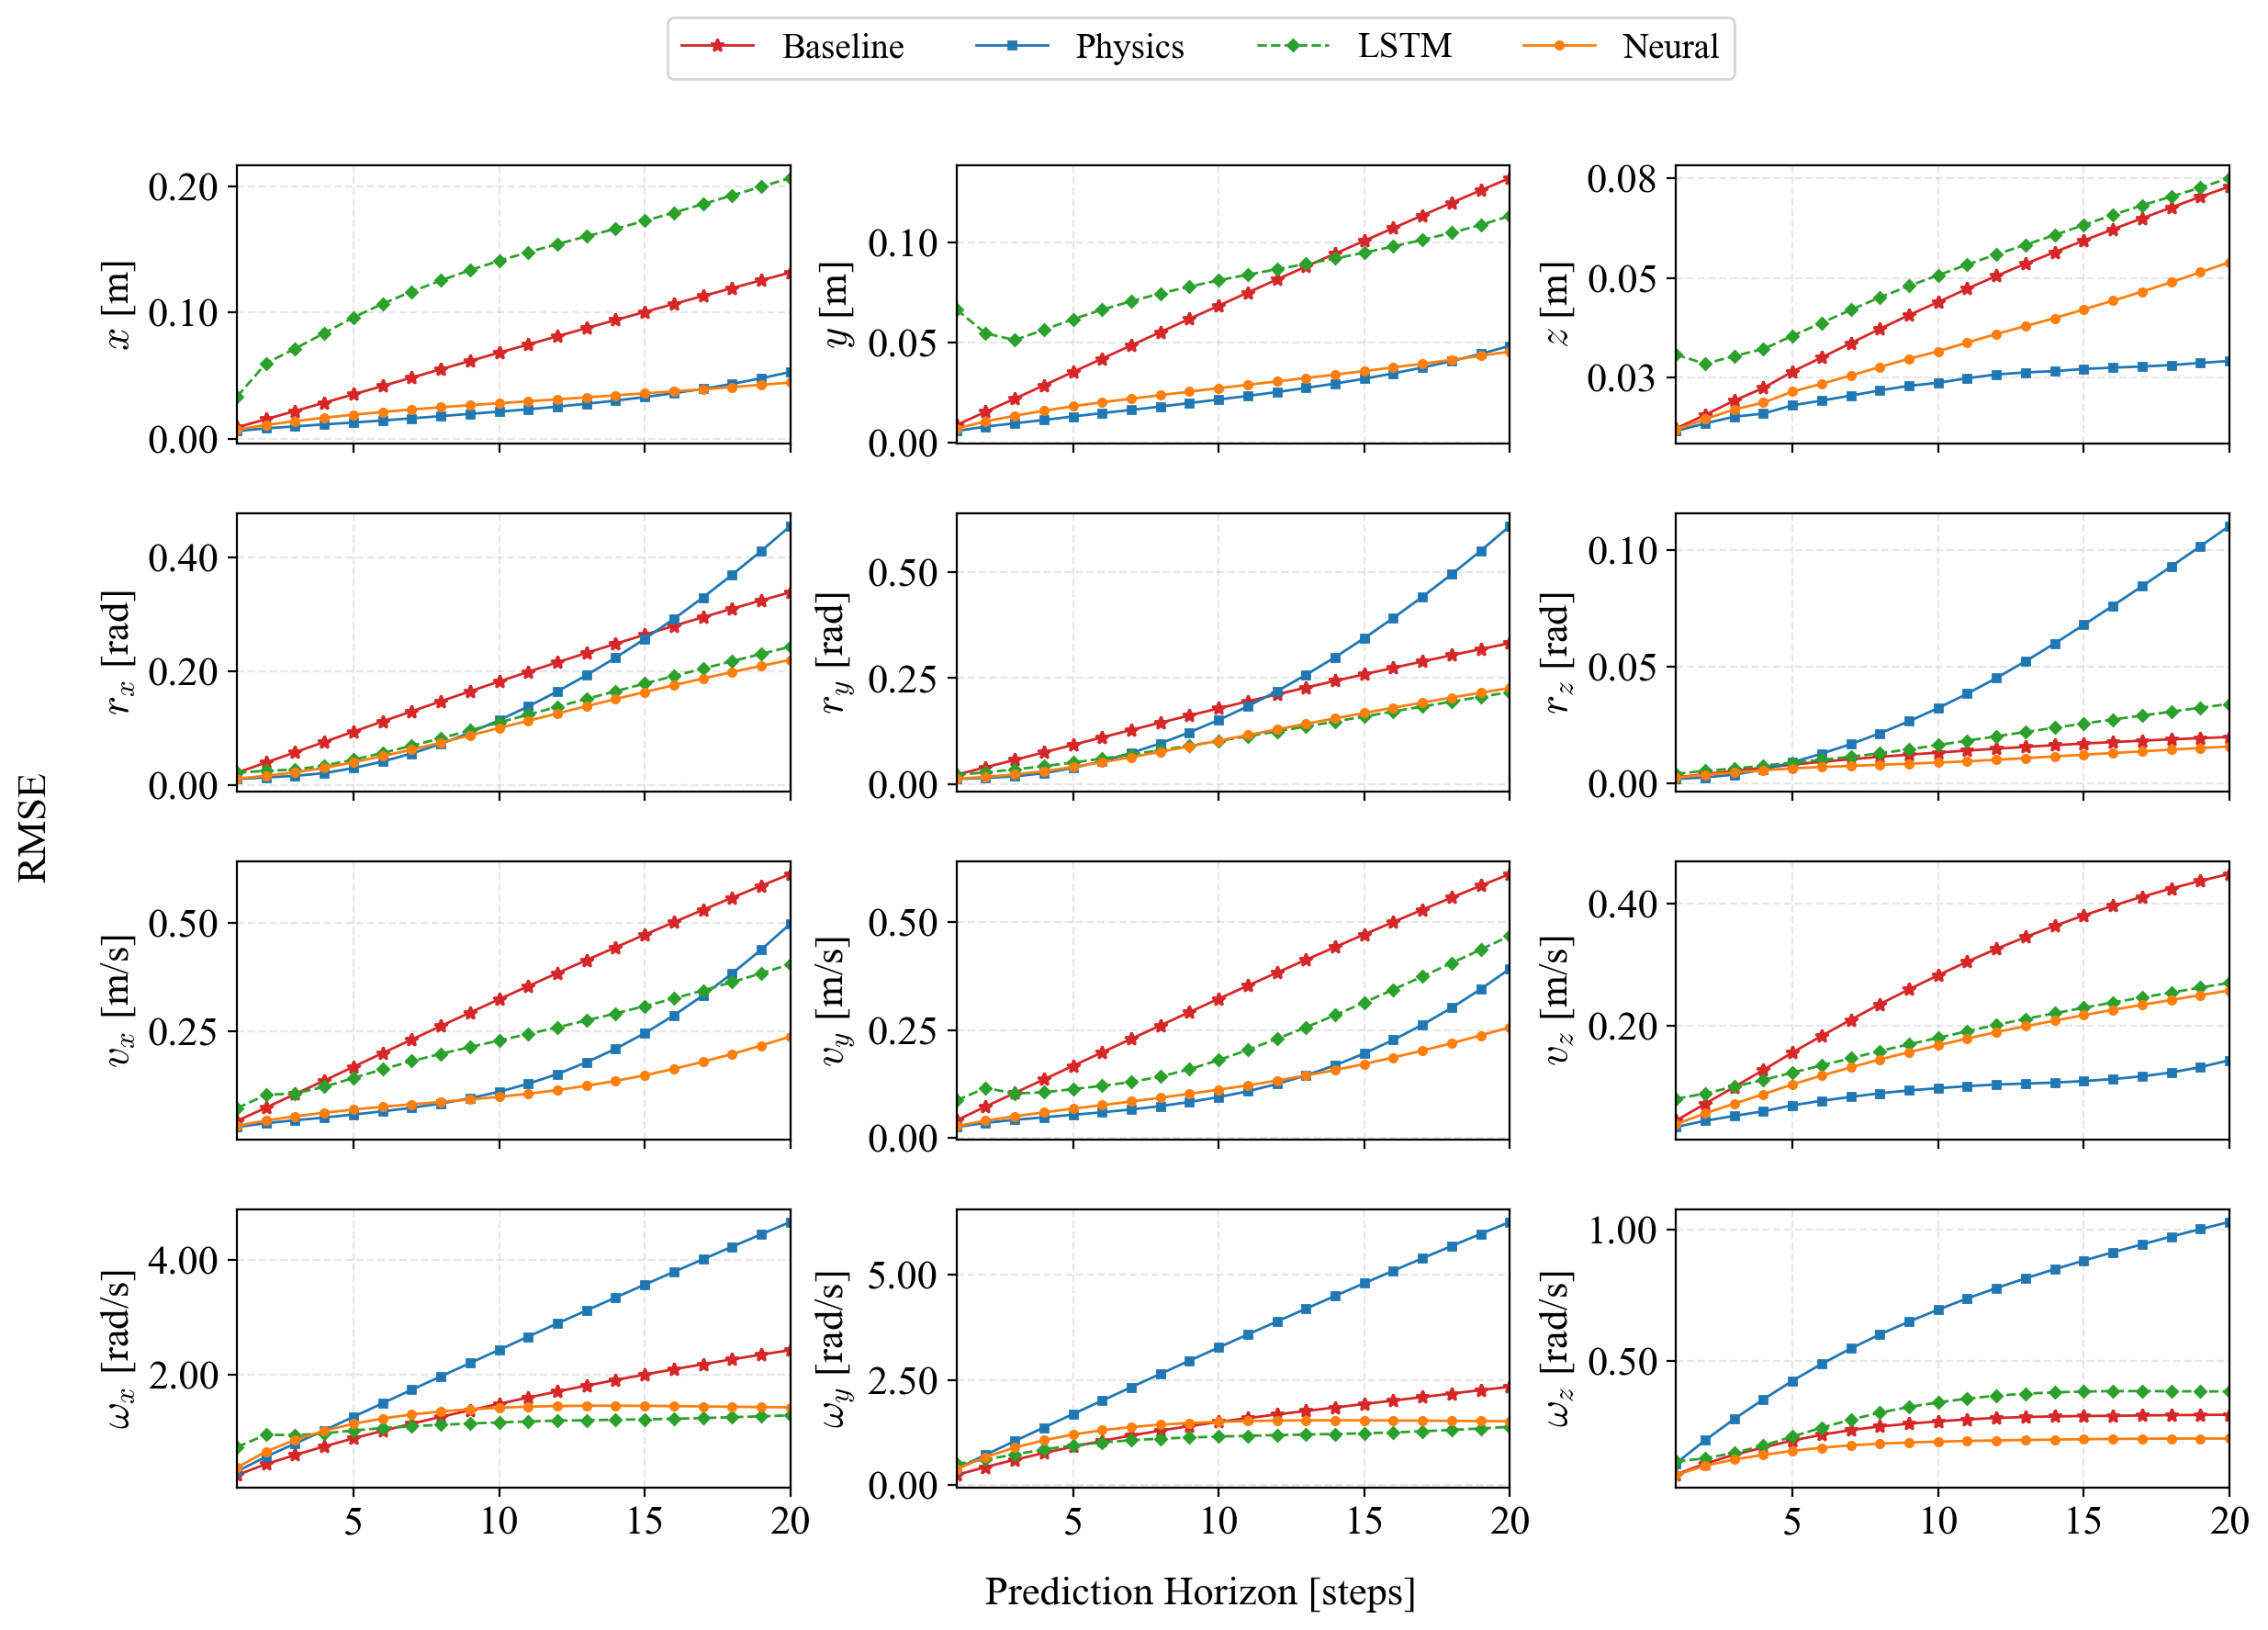

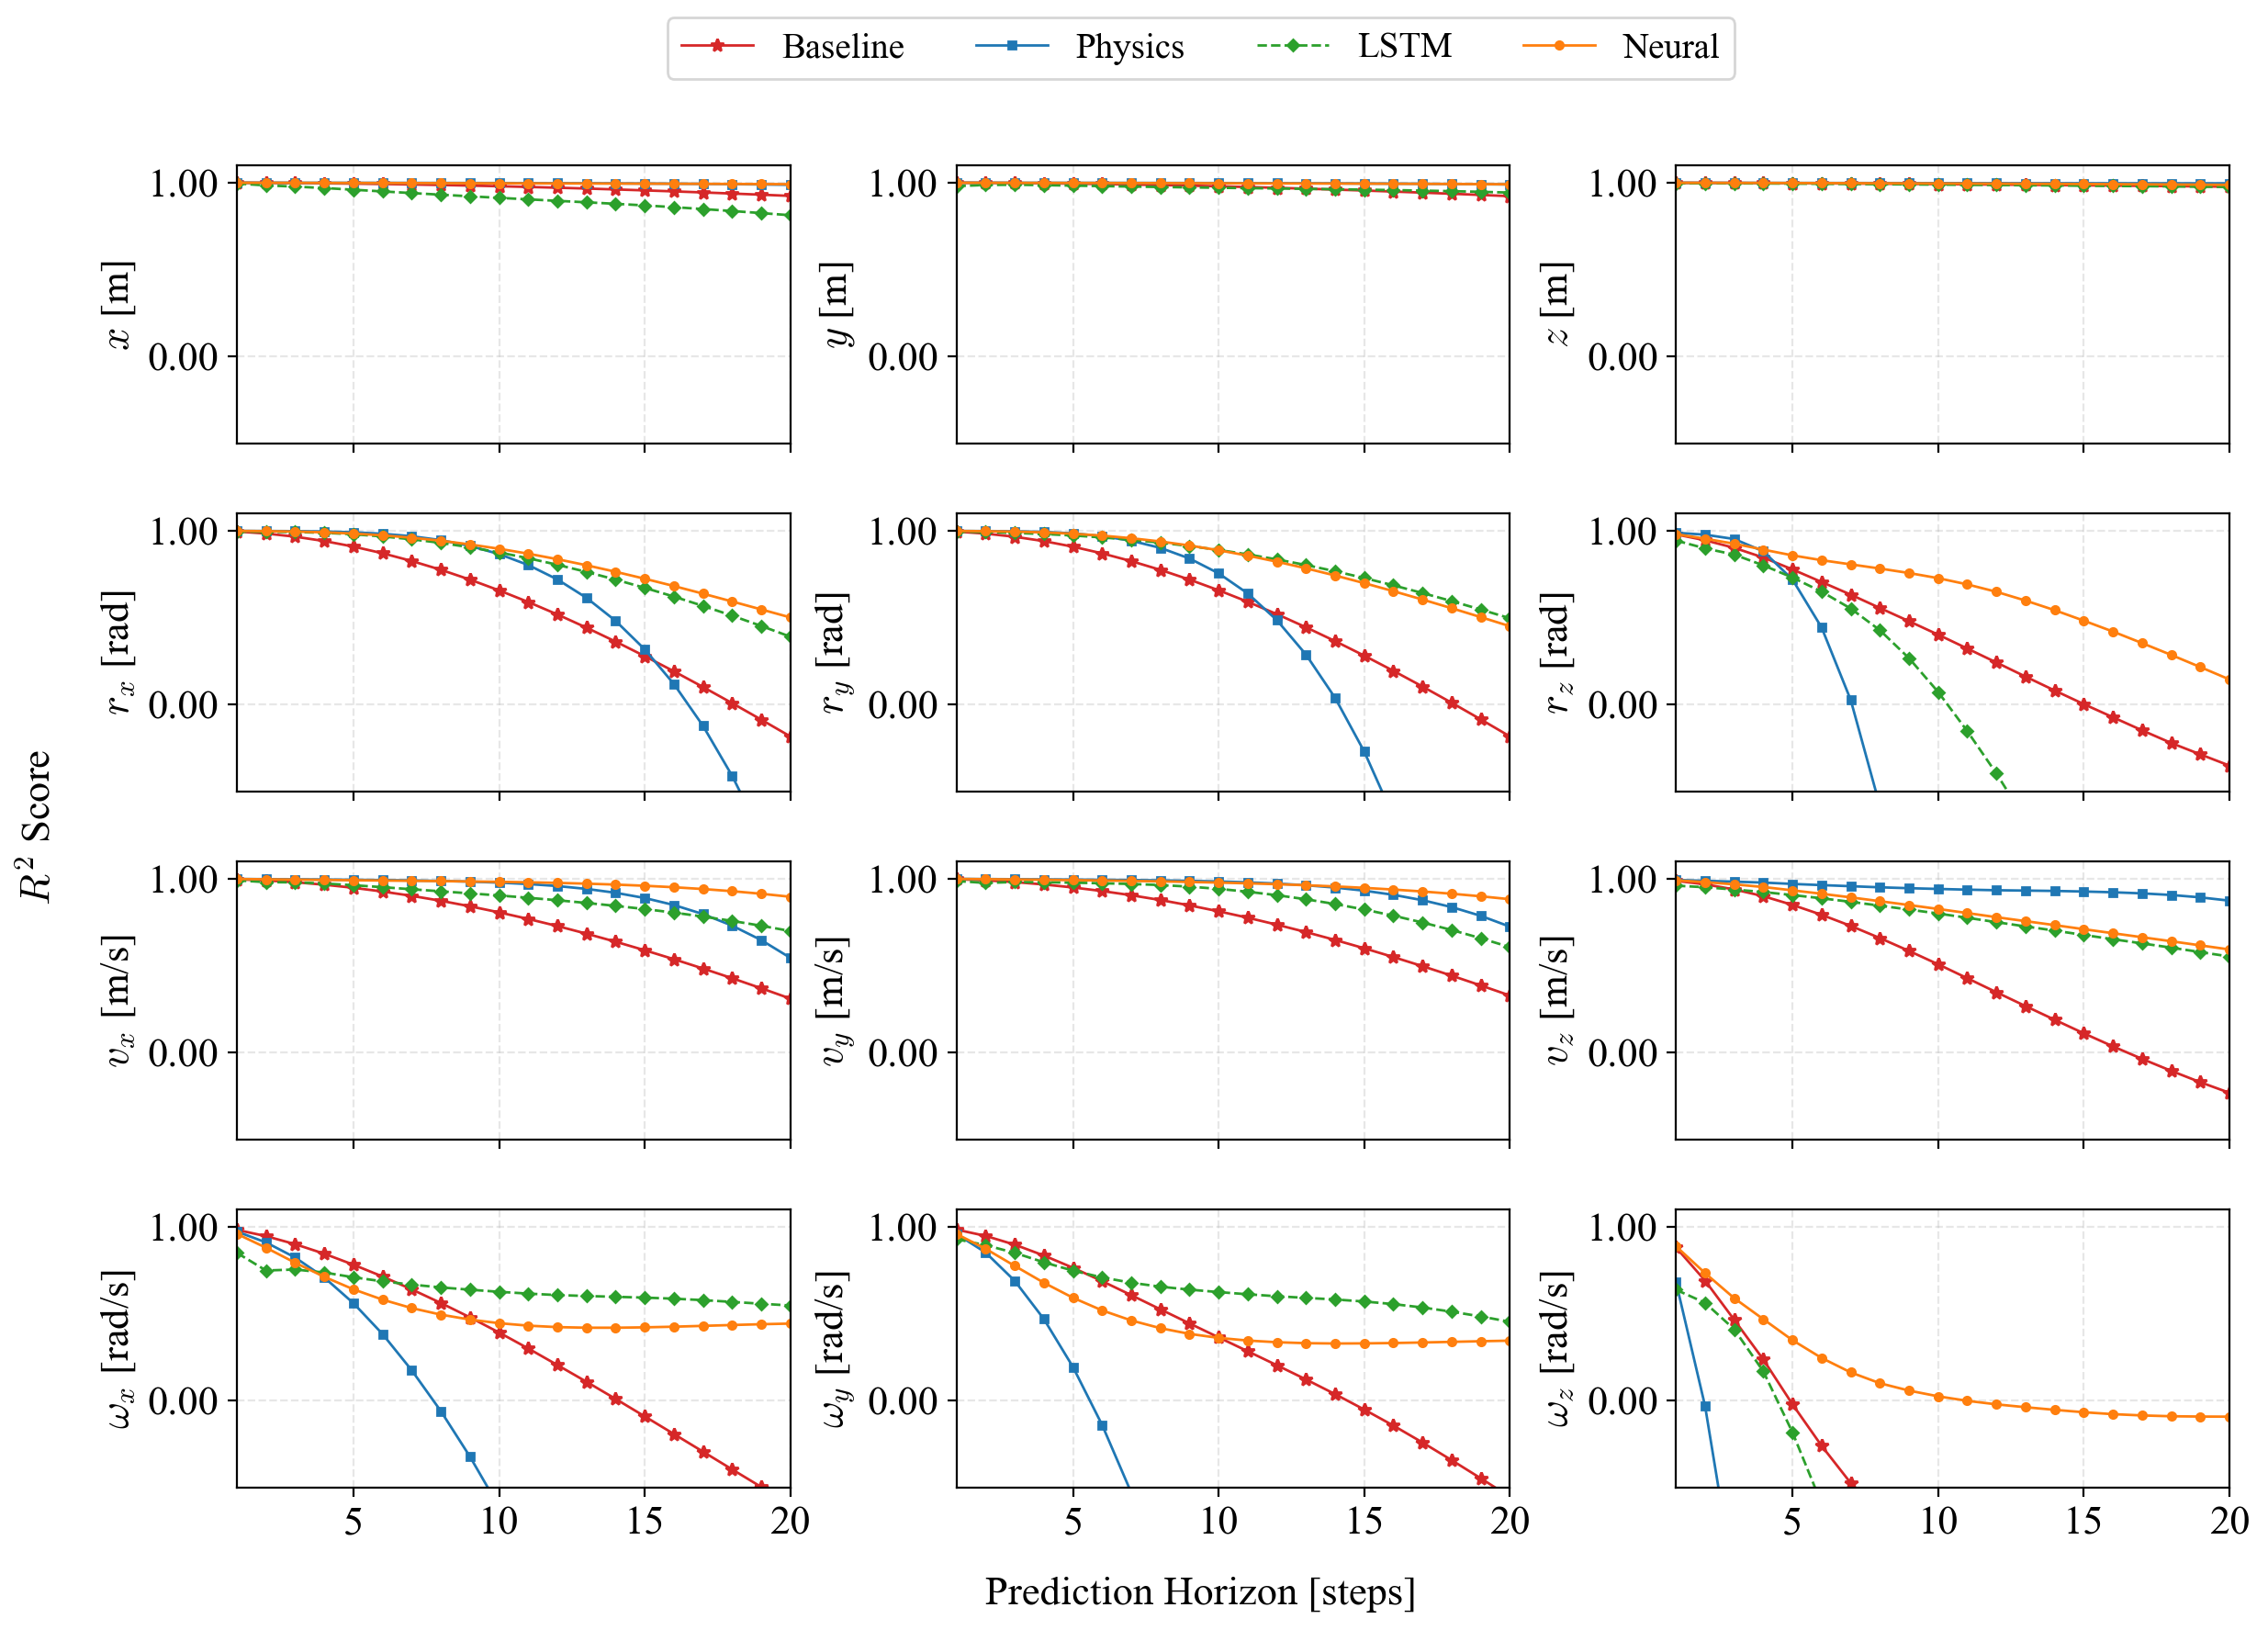

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --- Config ---
max_horizon = 20
use_log_y = False  # set True if you want log-scale RMSE

state_labels = [
    ['$x$ [m]', '$y$ [m]', '$z$ [m]'],
    [r'$r_x$ [rad]', r'$r_y$ [rad]', r'$r_z$ [rad]'],
    [r'$v_x$ [m/s]', r'$v_y$ [m/s]', r'$v_z$ [m/s]'],
    [r'$\omega_x$ [rad/s]', r'$\omega_y$ [rad/s]', r'$\omega_z$ [rad/s]']
]
state_names = ['x','y','z','rx','ry','rz','vx','vy','vz','wx','wy','wz']

# --- Helper to compute horizon metrics ---
def compute_horizon_metrics(df, state, max_horizon):
    horizons, rmses, r2s = [], [], []
    for h in range(1, max_horizon + 1):
        col = f"{state}_pred_h{h}"
        if col not in df.columns:
            continue
        # shift(-h+1) aligns true x(t+h) with pred_h
        true = df[state].shift(-h + 1).dropna()
        pred = df[col].dropna().iloc[:len(true)]

        err = true - pred
        horizons.append(h)
        rmses.append(np.sqrt(np.mean(err**2)))
        try:
            r2s.append(r2_score(true, pred))
        except ValueError:
            r2s.append(np.nan)
    return np.array(horizons), np.array(rmses), np.array(r2s)


# ============================================================
# --- Compute metrics per state ---
# ============================================================
metrics_lstm, metrics_base, metrics_neur, metrics_phys = {}, {}, {}, {}

for state in state_names:
    h_lstm, rmse_lstm, r2_lstm = compute_horizon_metrics(df_lstm, state, max_horizon)
    h_base, rmse_base, r2_base = compute_horizon_metrics(df_base, state, max_horizon)
    h_neur, rmse_neur, r2_neur = compute_horizon_metrics(df_neur, state, max_horizon)
    h_phys, rmse_phys, r2_phys = compute_horizon_metrics(df_phys, state, max_horizon)
    metrics_lstm[state] = (h_lstm, rmse_lstm, r2_lstm)
    metrics_base[state] = (h_base, rmse_base, r2_base)
    metrics_neur[state] = (h_neur, rmse_neur, r2_neur)
    metrics_phys[state] = (h_phys, rmse_phys, r2_phys)

# ============================================================
# === FIGURE 1: RMSE per horizon ===
# ============================================================
fig, axs = plt.subplots(4, 3, figsize=(14, 9), sharex=True, dpi=200)

for r in range(4):
    for c in range(3):
        idx = r * 3 + c
        if idx >= len(state_names):
            continue
        state = state_names[idx]
        ax = axs[r, c]

        h_lstm, rmse_lstm, _ = metrics_lstm[state]
        h_base, rmse_base, _ = metrics_base[state]
        h_neur, rmse_neur, _ = metrics_neur[state]
        h_phys, rmse_phys, _ = metrics_phys[state]


        ax.plot(h_base, rmse_base, '*-', color='tab:red', label='Baseline', markersize=5, linewidth=1)
        ax.plot(h_phys, rmse_phys, 's-', color='tab:blue', label='Physics', markersize=3, linewidth=1)
        ax.plot(h_lstm, rmse_lstm, 'D--', color='tab:green', label='LSTM', markersize=3, linewidth=1)
        ax.plot(h_neur, rmse_neur, 'o-', color='tab:orange', label='Neural', markersize=3, linewidth=1)

        ax.set_ylabel(state_labels[r][c])
        ax.grid(True, alpha=0.3)
        if use_log_y:
            ax.set_yscale('log')
        else:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))

fig.text(0.5, 0.03, "Prediction Horizon [steps]", ha='center', fontsize=16)
fig.text(0.04, 0.5, "RMSE", va='center', rotation='vertical', fontsize=16)

handles, labels = [], []
for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)
fig.legend(handles, labels, loc='upper center', ncols=4, bbox_to_anchor=(0.5, 1.0), fontsize=14)

plt.subplots_adjust(top=0.9, bottom=0.1, hspace=0.25, wspace=0.3)
plt.show()

# ============================================================
# === FIGURE 2: R² per horizon ===
# ============================================================
fig, axs = plt.subplots(4, 3, figsize=(14, 9), sharex=True, dpi=200)

for r in range(4):
    for c in range(3):
        idx = r * 3 + c
        if idx >= len(state_names):
            continue
        state = state_names[idx]
        ax = axs[r, c]

        h_lstm, _, r2_lstm = metrics_lstm[state]
        h_base, _, r2_base = metrics_base[state]
        h_neur, _, r2_neur = metrics_neur[state]
        h_phys, _, r2_phys = metrics_phys[state]

        ax.plot(h_base, r2_base, '*-', color='tab:red', label='Baseline', markersize=5, linewidth=1)
        ax.plot(h_phys, r2_phys, 's-', color='tab:blue', label='Physics', markersize=3, linewidth=1)
        ax.plot(h_lstm, r2_lstm, 'D--', color='tab:green', label='LSTM', markersize=3, linewidth=1)
        ax.plot(h_neur, r2_neur, 'o-', color='tab:orange', label='Neural', markersize=3, linewidth=1)


        ax.set_ylabel(state_labels[r][c])
        ax.set_ylim(-0.5, 1.1)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))

fig.text(0.5, 0.03, "Prediction Horizon [steps]", ha='center', fontsize=16)
fig.text(0.04, 0.5, r"$R^2$ Score", va='center', rotation='vertical', fontsize=16)

handles, labels = [], []
for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)
fig.legend(handles, labels, loc='upper center', ncols=4, bbox_to_anchor=(0.5, 1.0), fontsize=14)

plt.subplots_adjust(top=0.9, bottom=0.1, hspace=0.25, wspace=0.3)
plt.show()


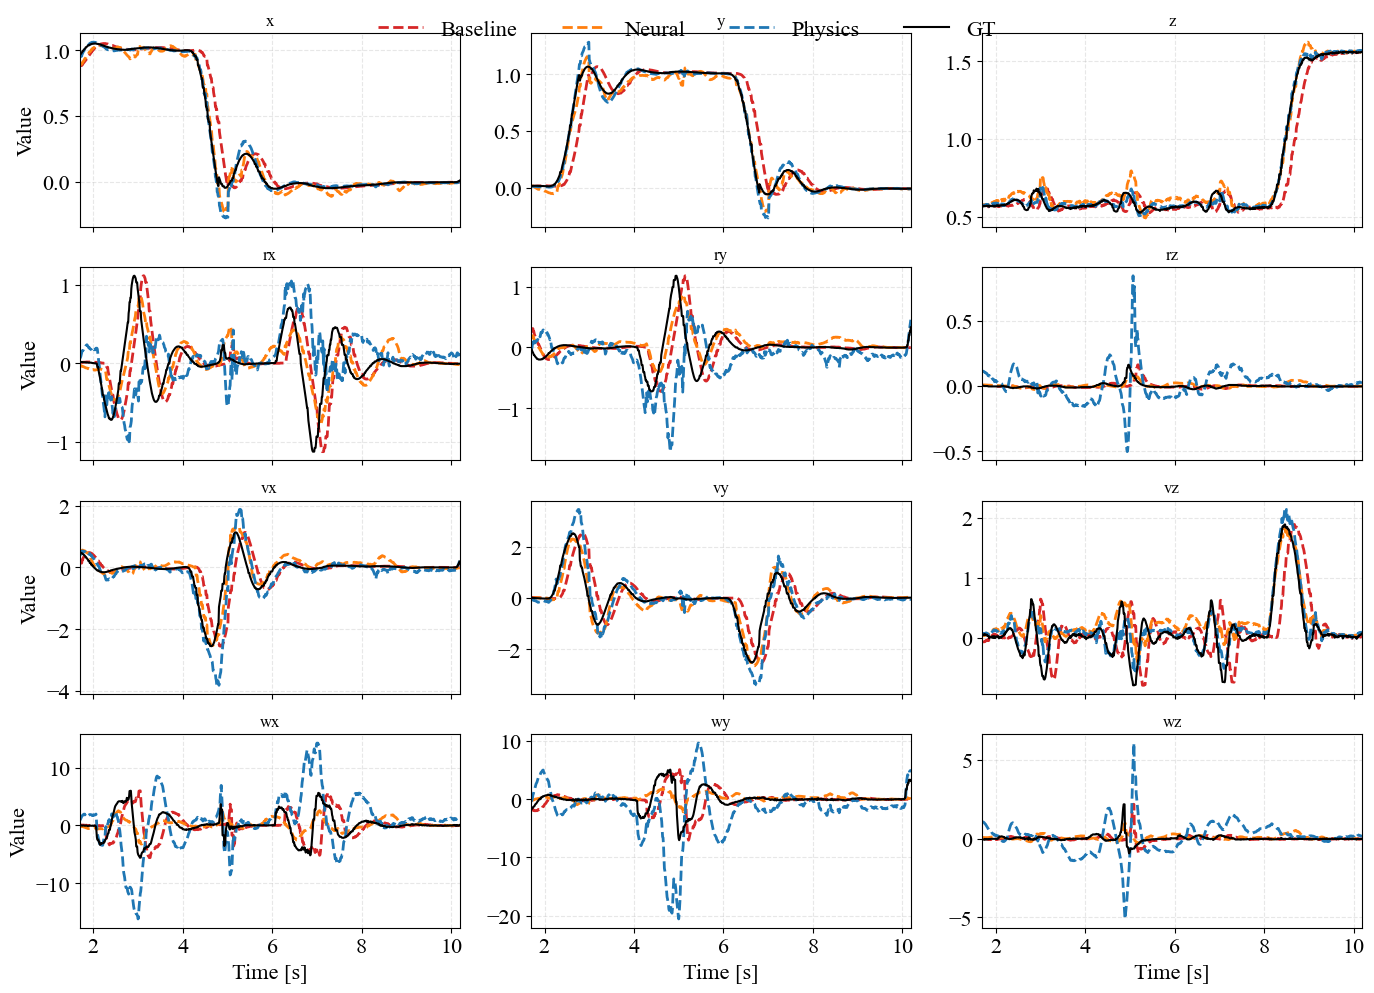

In [6]:
import matplotlib.pyplot as plt

def plot_multistate_predictions(df_base, df_lstm, df_neur, df_phys, h=50, N_start=0, N_end=None):
    """
    Create a 4x3 grid of time-series plots comparing true vs. predicted trajectories
    (h-step ahead) for each state variable.

    Args:
        df_base, df_lstm, df_neur : pd.DataFrame
            DataFrames with columns like 't', 'x', 'y', 'z', ... and corresponding 'state_pred_h{h}'.
        h : int
            Prediction horizon to visualize.
        N_start, N_end : int
            Range of samples to plot.
    """
    if N_end is None:
        N_end = len(df_base) - h

    # --- State order (12 total) ---
    states = [
        "x", "y", "z",
        "rx", "ry", "rz",
        "vx", "vy", "vz",
        "wx", "wy", "wz"
    ]

    fig, axes = plt.subplots(4, 3, figsize=(14, 10), sharex=True)
    axes = axes.flatten()

    t = df_base["t"].values

    for i, state in enumerate(states):
        ax = axes[i]
        pred_col = f"{state}_pred_h{h}"

        # Align predictions correctly: x_pred_hh[t] predicts x[t+h]
        true = df_base[state][N_start + h:N_end + h].rolling(1, min_periods=0, center=True).mean()
        base = df_base[pred_col][N_start:N_end].rolling(1, min_periods=0, center=True).mean()
        lstm = df_lstm[pred_col][N_start:N_end].rolling(1, min_periods=0, center=True).mean()
        neur = df_neur[pred_col][N_start:N_end].rolling(1, min_periods=0, center=True).mean()
        phys = df_phys[pred_col][N_start:N_end].rolling(1, min_periods=0, center=True).mean()

        ax.plot(t[N_start + h:N_end + h], base, '--', color='tab:red', label='Baseline', markersize=5, linewidth=2)
        # ax.plot(t[N_start + h:N_end + h], lstm, '--', color='tab:green', label='LSTM', markersize=3, linewidth=2)
        ax.plot(t[N_start + h:N_end + h], neur, '--', color='tab:orange', label='Neural', markersize=3, linewidth=2)
        ax.plot(t[N_start + h:N_end + h], phys, '--', color='tab:blue', label='Physics', markersize=3, linewidth=2)
        ax.plot(t[N_start + h:N_end + h], true, 'k-', label='GT')


        ax.set_title(state)
        ax.grid(alpha=0.3)
        if i % 3 == 0:
            ax.set_ylabel("Value")
        if i >= 9:
            ax.set_xlabel("Time [s]")

    # --- One shared legend ---
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
    plt.tight_layout()
    plt.show()

plot_multistate_predictions(df_base, df_lstm, df_neur, df_phys, h=20, N_start=150, N_end=1000)

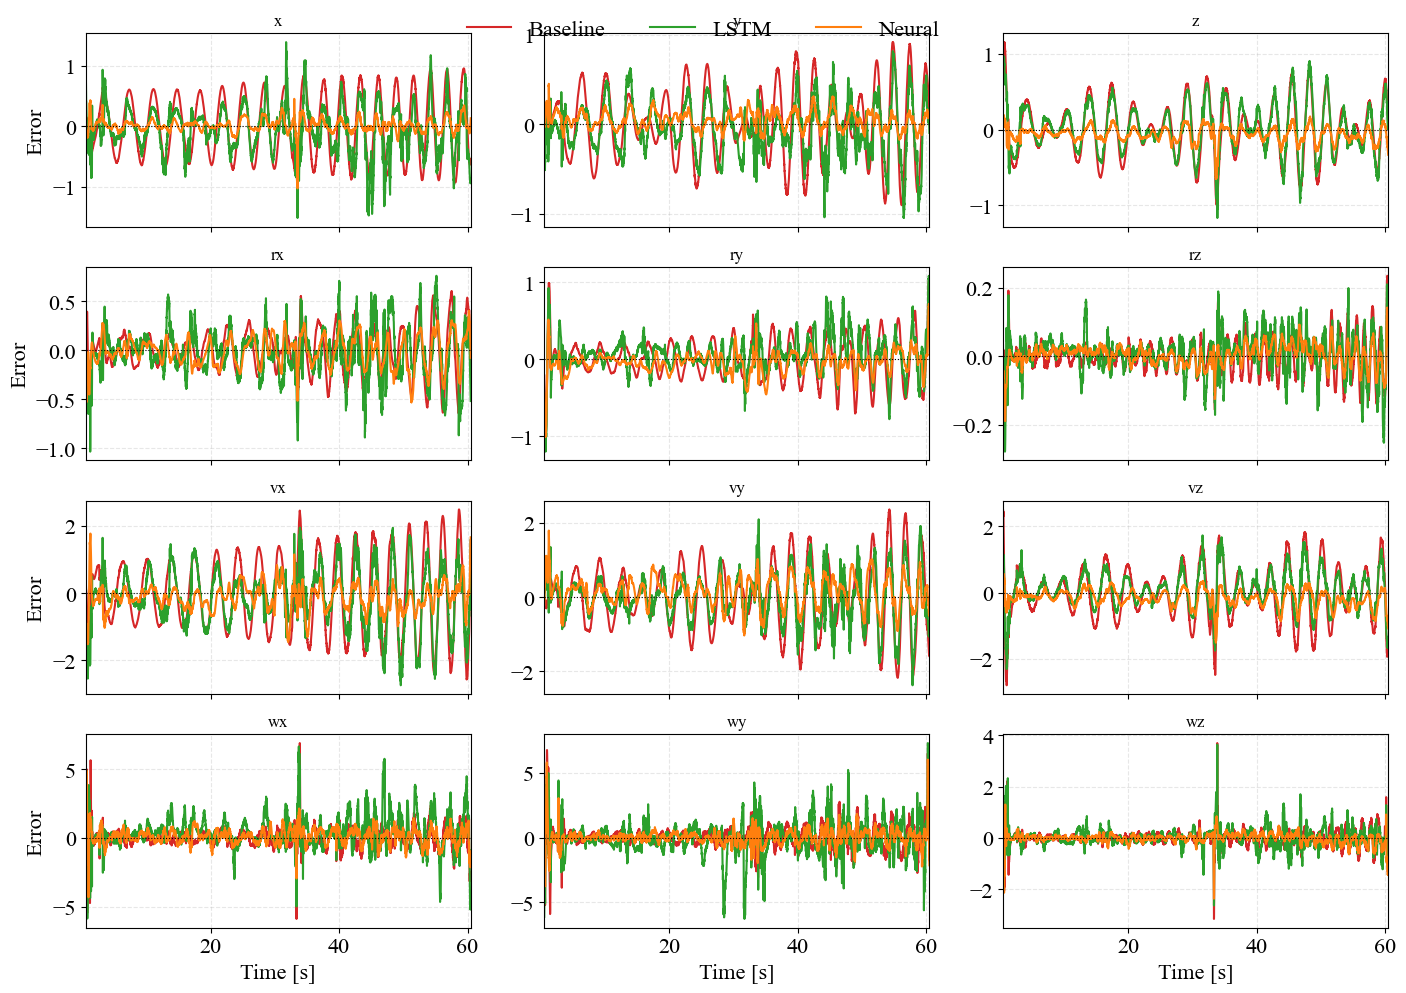

In [59]:
import matplotlib.pyplot as plt

def plot_multistate_errors(df_base, df_lstm, df_neur, h=50, N_start=0, N_end=None):
    """
    Create a 4x3 grid of time-series plots showing prediction errors (true - pred)
    for each state variable, over a given horizon h.

    Args:
        df_base, df_lstm, df_neur : pd.DataFrame
            DataFrames with columns like 't', 'x', 'y', 'z', ... and corresponding 'state_pred_h{h}'.
        h : int
            Prediction horizon.
        N_start, N_end : int
            Range of samples to plot.
    """
    if N_end is None:
        N_end = len(df_base) - h

    # --- State order (12 total) ---
    states = [
        "x", "y", "z",
        "rx", "ry", "rz",
        "vx", "vy", "vz",
        "wx", "wy", "wz"
    ]

    fig, axes = plt.subplots(4, 3, figsize=(14, 10), sharex=True)
    axes = axes.flatten()

    t = df_base["t"].values

    for i, state in enumerate(states):
        ax = axes[i]
        pred_col = f"{state}_pred_h{h}"

        # Align predictions correctly: x_pred_hh[t] predicts x[t+h]
        true = df_base[state].values[N_start + h:N_end + h]
        base = df_base[pred_col].values[N_start:N_end]
        lstm = df_lstm[pred_col].values[N_start:N_end]
        neur = df_neur[pred_col].values[N_start:N_end]

        # Compute errors
        err_base = true - base
        err_lstm = true - lstm
        err_neur = true - neur

        ax.plot(t[N_start + h:N_end + h], err_base, '-', color='tab:red', label='Baseline', linewidth=1.5)
        ax.plot(t[N_start + h:N_end + h], err_lstm, '-', color='tab:green', label='LSTM', linewidth=1.5)
        ax.plot(t[N_start + h:N_end + h], err_neur, '-', color='tab:orange', label='Neural', linewidth=1.5)
        ax.axhline(0, color='k', linewidth=0.8, linestyle=':')  # zero-error reference

        ax.set_title(state)
        ax.grid(alpha=0.3)
        if i % 3 == 0:
            ax.set_ylabel("Error")
        if i >= 9:
            ax.set_xlabel("Time [s]")

    # --- Shared legend ---
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)

    plt.tight_layout()
    plt.show()

plot_multistate_errors(df_base, df_lstm, df_neur, h=50, N_start=0, N_end=6000)